In [1]:
#feature analisis
#Add IHC as a feature to the best performing model (from CV ranking) and evaluate its impact

In [2]:
### import necessary packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

In [3]:
### import data
data= pd.read_csv("./brca_metabric_clinical_data.tsv", sep="\t")
data.head(10)

,Study ID,Patient ID,Sample ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,...,Relapse Free Status (Months),Relapse Free Status,Number of Samples Per Patient,Sample Type,Sex,3-Gene classifier subtype,TMB (nonsynonymous),Tumor Size,Tumor Stage,Patient's Vital Status
0,brca_metabric,MB-0000,MB-0000,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NO,claudin-low,...,140.500000,0:Not Recurred,1,Primary,Female,ER-/HER2-,0.000000,22.0,2.0,Living
1,brca_metabric,MB-0002,MB-0002,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumA,...,84.633333,0:Not Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,10.0,1.0,Living
2,brca_metabric,MB-0005,MB-0005,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,YES,LumB,...,153.300000,1:Recurred,1,Primary,Female,NaN,2.615035,15.0,2.0,Died of Disease
3,brca_metabric,MB-0006,MB-0006,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,YES,LumB,...,164.933333,0:Not Recurred,1,Primary,Female,NaN,1.307518,25.0,2.0,Living
4,brca_metabric,MB-0008,MB-0008,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,YES,LumB,...,18.800000,1:Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,40.0,2.0,Died of Disease
5,brca_metabric,MB-0010,MB-0010,78.77,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,NO,LumB,...,2.933333,1:Recurred,1,Primary,Female,ER+/HER2- High Prolif,5.230071,31.0,4.0,Died of Disease
6,brca_metabric,MB-0014,MB-0014,56.45,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,YES,LumB,...,164.333333,0:Not Recurred,1,Primary,Female,NaN,5.230071,10.0,2.0,Living
7,brca_metabric,MB-0020,MB-0020,70.00,MASTECTOMY,Breast Cancer,Breast Invasive Lobular Carcinoma,High,YES,Normal,...,11.900000,1:Recurred,1,Primary,Female,ER-/HER2-,0.000000,65.0,3.0,Died of Disease
8,brca_metabric,MB-0022,MB-0022,89.08,BREAST CONSERVING,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,NO,claudin-low,...,99.533333,0:Not Recurred,1,Primary,Female,NaN,1.307518,29.0,2.0,Died of Other Causes
9,brca_metabric,MB-0025,MB-0025,76.24,NaN,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NaN,NaN,...,128.000000,1:Recurred,1,Primary,Female,NaN,6.537589,34.0,2.0,NaN


In [4]:
### feature selection

# list of features to keep
keep_columns=["Age at Diagnosis", 
              "Cancer Type Detailed", 
              "Inferred Menopausal State", 
              "Tumor Size",
              "Lymph nodes examined positive",
              "3-Gene classifier subtype",
              "Pam50 + Claudin-low subtype",
              "Integrative Cluster",
              "ER Status",
              "PR Status",
              "HER2 Status",
              "Overall Survival (Months)"]

# remove other features
data = data[keep_columns].copy()

# confirm removal
print(data.columns)

# remove samples where Overall Survival is na
data = data.dropna(subset=["Overall Survival (Months)"])

Index(['Age at Diagnosis', 'Cancer Type Detailed', 'Inferred Menopausal State',
       'Tumor Size', 'Lymph nodes examined positive',
       '3-Gene classifier subtype', 'Pam50 + Claudin-low subtype',
       'Integrative Cluster', 'ER Status', 'PR Status', 'HER2 Status',
       'Overall Survival (Months)'],
      dtype='str')


In [5]:
###Inspect the raw data
data.info()

<class 'pandas.DataFrame'>
Index: 1981 entries, 0 to 1984
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age at Diagnosis               1981 non-null   float64
 1   Cancer Type Detailed           1981 non-null   str    
 2   Inferred Menopausal State      1980 non-null   str    
 3   Tumor Size                     1955 non-null   float64
 4   Lymph nodes examined positive  1905 non-null   float64
 5   3-Gene classifier subtype      1764 non-null   str    
 6   Pam50 + Claudin-low subtype    1980 non-null   str    
 7   Integrative Cluster            1980 non-null   str    
 8   ER Status                      1981 non-null   str    
 9   PR Status                      1980 non-null   str    
 10  HER2 Status                    1980 non-null   str    
 11  Overall Survival (Months)      1981 non-null   float64
dtypes: float64(4), str(8)
memory usage: 201.2 KB


In [6]:
# Missing data por feature
missing_df = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_pct": (data.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

print(missing_df)

                               missing_count  missing_pct
3-Gene classifier subtype                217        10.95
Lymph nodes examined positive             76         3.84
Tumor Size                                26         1.31
Inferred Menopausal State                  1         0.05
Pam50 + Claudin-low subtype                1         0.05
Integrative Cluster                        1         0.05
PR Status                                  1         0.05
HER2 Status                                1         0.05
Age at Diagnosis                           0         0.00
Cancer Type Detailed                       0         0.00
ER Status                                  0         0.00
Overall Survival (Months)                  0         0.00


In [7]:
## Check for missing values in the 3-Gene classifier subtype
col = "3-Gene classifier subtype"

print("Total rows:", len(data))
print("Missing (count):", data[col].isna().sum())
print("Missing (%):", round(data[col].isna().mean() * 100, 2), "%")

print("\nValues and frequencies (including missing):")
print(data[col].value_counts(dropna=False))

Total rows: 1981
Missing (count): 217
Missing (%): 10.95 %

Values and frequencies (including missing):
3-Gene classifier subtype
ER+/HER2- Low Prolif     640
ER+/HER2- High Prolif    617
ER-/HER2-                309
NaN                      217
HER2+                    198
Name: count, dtype: int64


In [8]:
### group rare cancer types together

top3 = data["Cancer Type Detailed"].value_counts().nlargest(3).index

data["Cancer Type Grouped"] = data["Cancer Type Detailed"].apply(
    lambda x: x if x in top3 else "Other")

print(data["Cancer Type Grouped"].value_counts())

Cancer Type Grouped
Breast Invasive Ductal Carcinoma             1538
Breast Mixed Ductal and Lobular Carcinoma     211
Breast Invasive Lobular Carcinoma             146
Other                                          86
Name: count, dtype: int64


Numeric features: ['Age at Diagnosis', 'Tumor Size', 'Lymph nodes examined positive', 'Overall Survival (Months)']


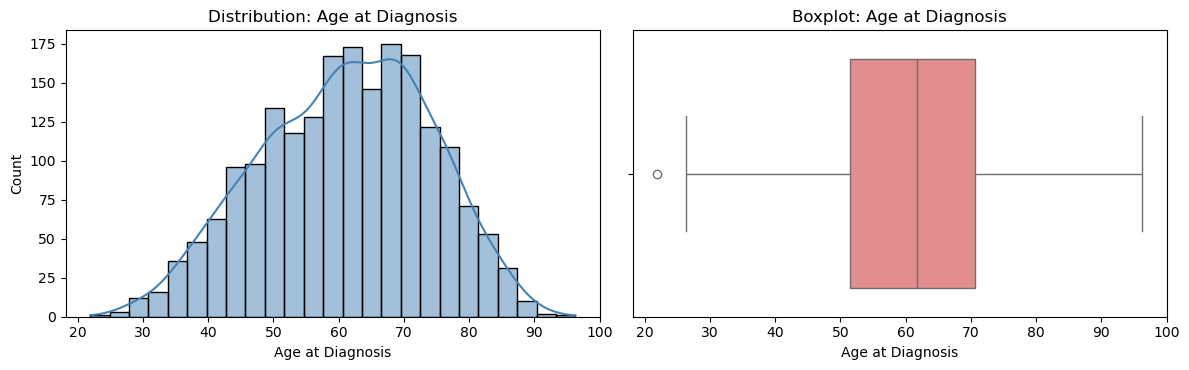

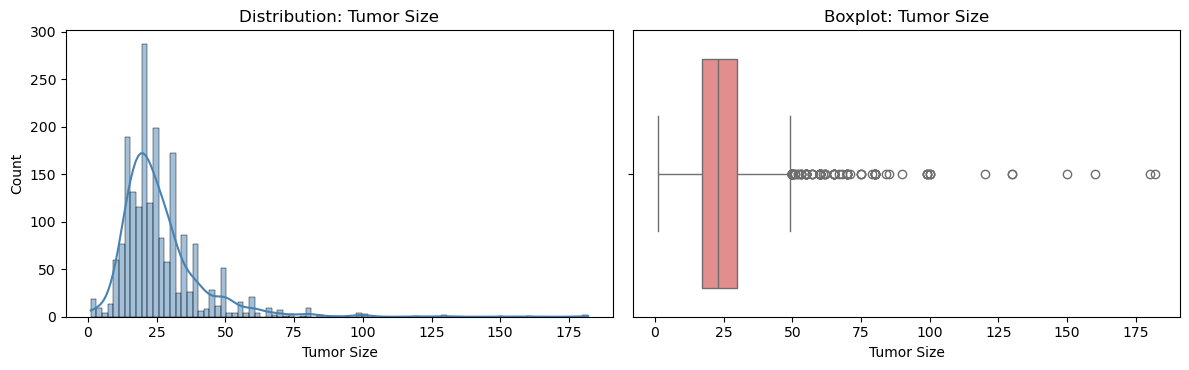

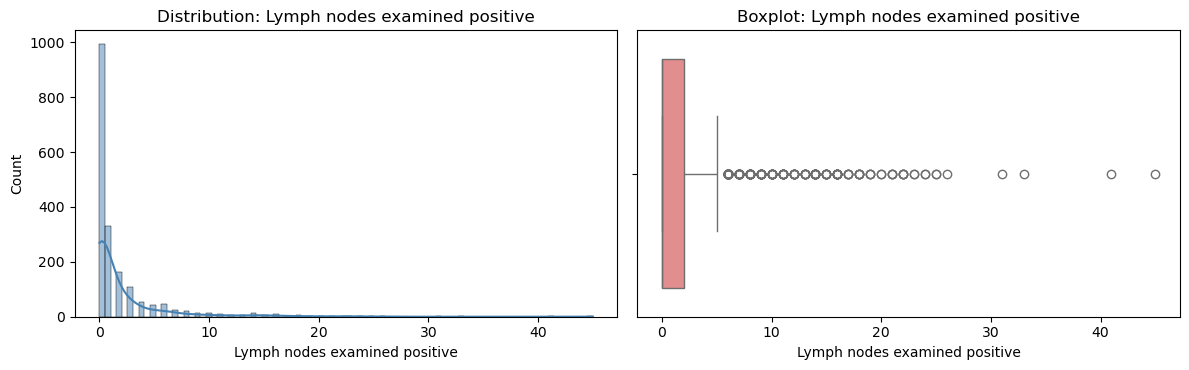

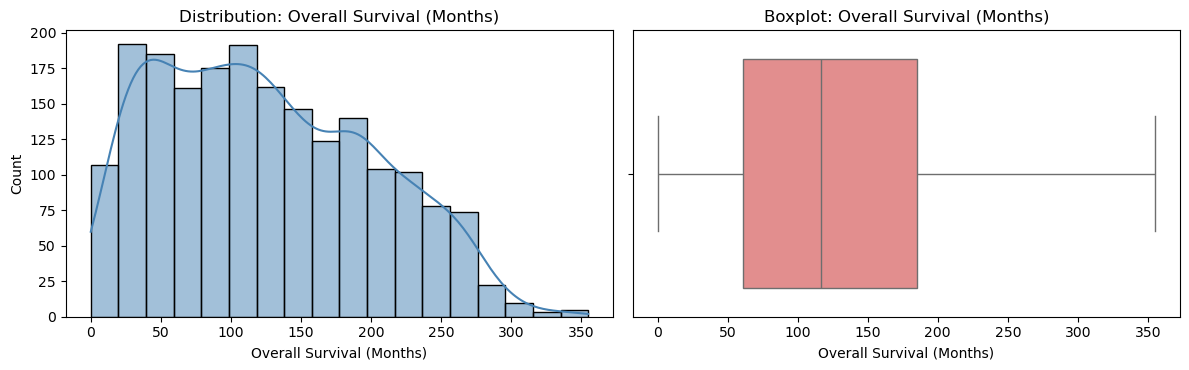

,feature,iqr_outliers,iqr_pct,zscore_outliers,zscore_pct
2,Lymph nodes examined positive,210,10.60,50,2.52
1,Tumor Size,151,7.62,30,1.51
0,Age at Diagnosis,1,0.05,1,0.05
3,Overall Survival (Months),0,0.00,1,0.05


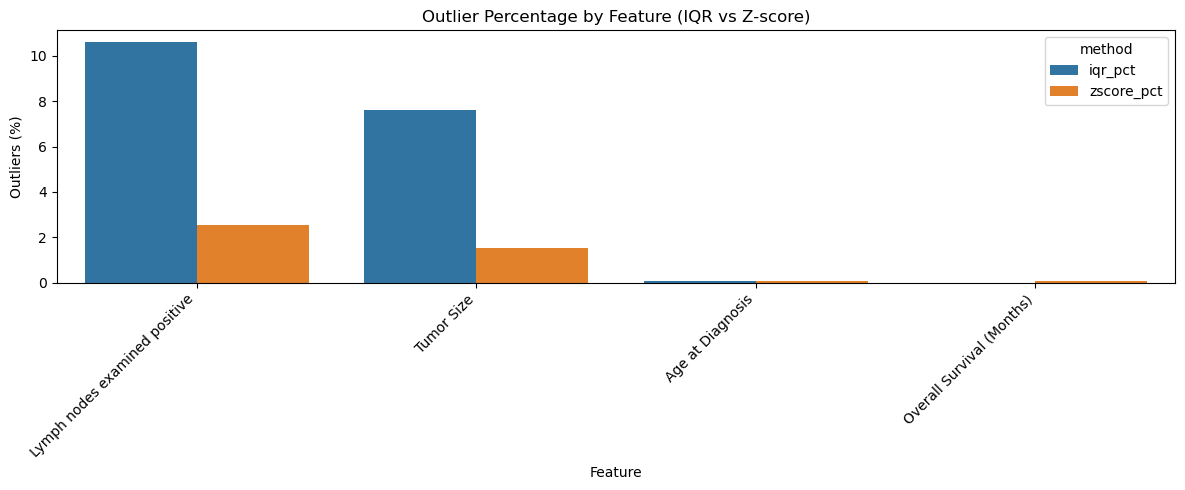

In [9]:
### visualize features and evaluate outliers (all numeric features)

# 1) Select numeric features
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric features:", numeric_cols)

if len(numeric_cols) == 0:
    print("No numeric features found for outlier analysis.")
else:
    # 2) Visual inspection: histogram + boxplot for each numeric feature
    for col in numeric_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

        sns.histplot(data[col].dropna(), kde=True, ax=axes[0], color="steelblue")
        axes[0].set_title(f"Distribution: {col}")
        axes[0].set_xlabel(col)

        sns.boxplot(x=data[col], ax=axes[1], color="lightcoral")
        axes[1].set_title(f"Boxplot: {col}")
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()

    # 3) Quantitative outlier evaluation using IQR and Z-score
    outlier_rows = []
    n_rows = len(data)

    for col in numeric_cols:
        s = data[col].dropna()
        if len(s) == 0:
            outlier_rows.append({
                "feature": col,
                "iqr_outliers": 0,
                "iqr_pct": 0.0,
                "zscore_outliers": 0,
                "zscore_pct": 0.0
            })
            continue

        # IQR method
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        iqr_mask = (data[col] < lower) | (data[col] > upper)
        iqr_count = int(iqr_mask.fillna(False).sum())

        # Z-score method
        std = s.std(ddof=0)
        if std == 0:
            z_count = 0
        else:
            z_scores = (data[col] - s.mean()) / std
            z_mask = z_scores.abs() > 3
            z_count = int(z_mask.fillna(False).sum())

        outlier_rows.append({
            "feature": col,
            "iqr_outliers": iqr_count,
            "iqr_pct": round((iqr_count / n_rows) * 100, 2),
            "zscore_outliers": z_count,
            "zscore_pct": round((z_count / n_rows) * 100, 2),
        })

    outlier_summary = pd.DataFrame(outlier_rows).sort_values("iqr_outliers", ascending=False)
    display(outlier_summary)

    # 4) Summary bar plot for easy comparison
    plot_out = outlier_summary.melt(
        id_vars="feature",
        value_vars=["iqr_pct", "zscore_pct"],
        var_name="method",
        value_name="outlier_percent"
    )

    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_out, x="feature", y="outlier_percent", hue="method")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Outliers (%)")
    plt.xlabel("Feature")
    plt.title("Outlier Percentage by Feature (IQR vs Z-score)")
    plt.tight_layout()
    plt.show()

In [10]:
### outlier treatment after visualization

# Cap fixed thresholds in the full dataset before split
data["Tumor Size"] = data["Tumor Size"].clip(upper=100)
data["Lymph nodes examined positive"] = data["Lymph nodes examined positive"].clip(upper=10)

print("Tumor Size max after cap:", data["Tumor Size"].max())
print("Lymph nodes max after cap:", data["Lymph nodes examined positive"].max())


Tumor Size max after cap: 100.0
Lymph nodes max after cap: 10.0


In [11]:
### generate a new feature of immunohistochemistry subtype based on ER/PR/HER2 status

def ihc_subtype(row):
    er = str(row.get("ER Status", "")).strip().lower()
    pr = str(row.get("PR Status", "")).strip().lower()
    her2 = str(row.get("HER2 Status", "")).strip().lower()

    if her2 == "positive":
        return "HER2"
    elif er == "positive" or pr == "positive":
        return "Luminal"
    elif er == "negative" and pr == "negative" and her2 == "negative":
        return "Triple Negative"
    else:
        return "Unknown"

if "PR Status" not in data.columns:
    print("Warning: PR Status is missing. Re-run cell 3 first to include PR Status in keep_columns.")

data["IHC Subtype"] = data.apply(ihc_subtype, axis=1)

print(data["IHC Subtype"].value_counts(dropna=False))

# Check for missing values in the new feature
print(data["IHC Subtype"].isna().sum())

#delate columns "ER Status", "PR Status", "HER2 Status"
data = data.drop(columns=["ER Status", "PR Status", "HER2 Status"])

IHC Subtype
Luminal            1414
Triple Negative     320
HER2                247
Name: count, dtype: int64
0


In [12]:
### Discretize overall survival (months) into 2 groups

for index, row in data.iterrows():
    if row["Overall Survival (Months)"]>=60:
        data.loc[index, "Survival Duration"] = ">=5 years"
    else:
        data.loc[index, "Survival Duration"] = "<5 years"

In [13]:
### split predictors and response

predictors=["Age at Diagnosis", 
              "Cancer Type Grouped", 
              "Inferred Menopausal State", 
              "Tumor Size",
              "Lymph nodes examined positive",
              "3-Gene classifier subtype",
              "Pam50 + Claudin-low subtype",
              "Integrative Cluster", 
              "IHC Subtype"]

x= data[predictors]
y=data["Survival Duration"]

In [14]:
### split into test and train data 
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42)

In [15]:
### impute missing predictor values

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# check NaNs
print(x_train.isna().sum())
print(x_test.isna().sum())

# impute menopausal status based on age
mask = x_test["Inferred Menopausal State"].isna()
x_test.loc[mask, "Inferred Menopausal State"] = np.where(
    x_test.loc[mask, "Age at Diagnosis"] < 52,
    "Pre",
    "Post")

# impute tumor size from training median
tumor_size_median = x_train["Tumor Size"].median()
x_train["Tumor Size"] = x_train["Tumor Size"].fillna(tumor_size_median)
x_test["Tumor Size"] = x_test["Tumor Size"].fillna(tumor_size_median)

# impute lymph nodes from training median
lymph_node_median = x_train["Lymph nodes examined positive"].median()
x_train["Lymph nodes examined positive"] = x_train["Lymph nodes examined positive"].fillna(lymph_node_median)
x_test["Lymph nodes examined positive"] = x_test["Lymph nodes examined positive"].fillna(lymph_node_median)

# special imputation for 3-gene classifier using KNN (fit on train only)
target_col = "3-Gene classifier subtype"
feature_cols = [c for c in x_train.columns if c != target_col]

train_known = x_train[x_train[target_col].notna()].copy()
train_missing = x_train[x_train[target_col].isna()].copy()
test_missing = x_test[x_test[target_col].isna()].copy()

if len(train_known) >= 2:
    num_cols = train_known[feature_cols].select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in feature_cols if c not in num_cols]

    preprocess = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ]
    )

    # odd k and not larger than available train rows
    k = int(np.sqrt(len(train_known)))
    if k % 2 == 0:
        k += 1
    k = max(1, min(k, len(train_known)))

    knn_model = Pipeline(steps=[
        ("prep", preprocess),
        ("knn", KNeighborsClassifier(n_neighbors=k, weights="distance")),
    ])

    knn_model.fit(train_known[feature_cols], train_known[target_col])

    if len(train_missing) > 0:
        x_train.loc[train_missing.index, target_col] = knn_model.predict(train_missing[feature_cols])

    if len(test_missing) > 0:
        x_test.loc[test_missing.index, target_col] = knn_model.predict(test_missing[feature_cols])
else:
    # fallback if there are not enough known labels in train
    three_gene_mode = x_train[target_col].mode()[0]
    x_train[target_col] = x_train[target_col].fillna(three_gene_mode)
    x_test[target_col] = x_test[target_col].fillna(three_gene_mode)

# impute Pam50 using training mode
pam50_mode = x_train["Pam50 + Claudin-low subtype"].mode()[0]
x_train["Pam50 + Claudin-low subtype"] = x_train["Pam50 + Claudin-low subtype"].fillna(pam50_mode)
x_test["Pam50 + Claudin-low subtype"] = x_test["Pam50 + Claudin-low subtype"].fillna(pam50_mode)

# impute IntCluster using training mode
int_cluster_mode = x_train["Integrative Cluster"].mode()[0]
x_train["Integrative Cluster"] = x_train["Integrative Cluster"].fillna(int_cluster_mode)
x_test["Integrative Cluster"] = x_test["Integrative Cluster"].fillna(int_cluster_mode)

print("\n3-Gene missing after KNN imputation (train):", x_train[target_col].isna().sum())
print("3-Gene missing after KNN imputation (test):", x_test[target_col].isna().sum())


Age at Diagnosis                   0
Cancer Type Grouped                0
Inferred Menopausal State          1
Tumor Size                        19
Lymph nodes examined positive     65
3-Gene classifier subtype        182
Pam50 + Claudin-low subtype        1
Integrative Cluster                1
IHC Subtype                        0
dtype: int64
Age at Diagnosis                  0
Cancer Type Grouped               0
Inferred Menopausal State         0
Tumor Size                        7
Lymph nodes examined positive    11
3-Gene classifier subtype        35
Pam50 + Claudin-low subtype       0
Integrative Cluster               0
IHC Subtype                       0
dtype: int64

3-Gene missing after KNN imputation (train): 0
3-Gene missing after KNN imputation (test): 0


In [16]:
# confirm NaNs are removed
print(x_train.isna().sum())
print(x_test.isna().sum())

Age at Diagnosis                 0
Cancer Type Grouped              0
Inferred Menopausal State        1
Tumor Size                       0
Lymph nodes examined positive    0
3-Gene classifier subtype        0
Pam50 + Claudin-low subtype      0
Integrative Cluster              0
IHC Subtype                      0
dtype: int64
Age at Diagnosis                 0
Cancer Type Grouped              0
Inferred Menopausal State        0
Tumor Size                       0
Lymph nodes examined positive    0
3-Gene classifier subtype        0
Pam50 + Claudin-low subtype      0
Integrative Cluster              0
IHC Subtype                      0
dtype: int64


In [17]:
### separate x train and x test for each model

# Model 1 - Baseline
x1=["Age at Diagnosis", 
    "Cancer Type Grouped", 
    "Inferred Menopausal State", 
    "Tumor Size",
    "Lymph nodes examined positive",
    "IHC Subtype"]
x1_train= x_train[x1]
x1_test= x_test[x1]

# Model 2 - Baseline + 3-Gene Classifier
x2= x1 + ["3-Gene classifier subtype"]
x2_train= x_train[x2]
x2_test= x_test[x2] 

# Model 3 - Baseline+ Pam50
x3= x1 + ["Pam50 + Claudin-low subtype"]
x3_train= x_train[x3]
x3_test= x_test[x3]

# Model 4 - Baseline + Integrative Cluster
x4= x1 + ["Integrative Cluster"]
x4_train= x_train[x4]
x4_test= x_test[x4]

# Model 5 - 3-Gene Classifier
x5= ["3-Gene classifier subtype"]
x5_train= x_train[x5]
x5_test= x_test[x5]

#Model 6 - PAM50
x6= ["Pam50 + Claudin-low subtype"]
x6_train= x_train[x6]
x6_test= x_test[x6] 

# Model 7 - Integrative Cluster
x7= ["Integrative Cluster"]
x7_train= x_train[x7]
x7_test= x_test[x7]



In [18]:
### One hot encode

x1_train = pd.get_dummies(x1_train)
x1_test = pd.get_dummies(x1_test)

x2_train = pd.get_dummies(x2_train)
x2_test = pd.get_dummies(x2_test)

x3_train = pd.get_dummies(x3_train)
x3_test = pd.get_dummies(x3_test)

x4_train = pd.get_dummies(x4_train)
x4_test = pd.get_dummies(x4_test)

x5_train = pd.get_dummies(x5_train)
x5_test = pd.get_dummies(x5_test)

x6_train = pd.get_dummies(x6_train)
x6_test = pd.get_dummies(x6_test)

x7_train = pd.get_dummies(x7_train)
x7_test = pd.get_dummies(x7_test)


In [19]:
### save datasets
x1_train.to_csv("./x1_train.csv", index=False)
x1_test.to_csv("./x1_test.csv", index=False)

x2_train.to_csv("./x2_train.csv", index=False)
x2_test.to_csv("./x2_test.csv", index=False)

x3_train.to_csv("./x3_train.csv", index=False)
x3_test.to_csv("./x3_test.csv", index=False)

x4_train.to_csv("./x4_train.csv", index=False)
x4_test.to_csv("./x4_test.csv", index=False)

x5_train.to_csv("./x5_train.csv", index=False)
x5_test.to_csv("./x5_test.csv", index=False)

x6_train.to_csv("./x6_train.csv", index=False)
x6_test.to_csv("./x6_test.csv", index=False)

x7_train.to_csv("./x7_train.csv", index=False)
x7_test.to_csv("./x7_test.csv", index=False)

y_train.to_csv("./y_train.csv", index=False)
y_test.to_csv("./y_test.csv", index=False)

/opt/miniconda3/envs/bmif802/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:974: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/miniconda3/envs/bmif802/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 167, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/bmif802/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 463, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/bmif802/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/bmif802/lib/python3.12/site-packages/sklearn/metrics/_classification.py", line 2649, in p

Logistic regression metrics by model


/opt/miniconda3/envs/bmif802/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:974: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/miniconda3/envs/bmif802/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 167, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/bmif802/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 463, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/bmif802/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/bmif802/lib/python3.12/site-packages/sklearn/metrics/_classification.py", line 2649, in p

,Model,Train_Accuracy,Test_Accuracy,Train_F1,Test_F1,Train_ROC_AUC,Test_ROC_AUC,CV_Accuracy_mean,CV_Accuracy_std,CV_F1_mean,CV_F1_std,CV_ROC_AUC_mean,CV_ROC_AUC_std
0,Baseline + Integrative Cluster,0.6862,0.6524,0.7694,0.7425,0.7385,0.7225,0.6761,0.0339,NaN,NaN,0.7159,0.0361
1,Baseline + PAM50,0.7027,0.6574,0.7852,0.7444,0.7334,0.7194,0.6843,0.0181,NaN,NaN,0.7133,0.0201
2,Baseline + 3-Gene Classifier,0.6900,0.6524,0.7743,0.7454,0.7253,0.7218,0.6806,0.0305,NaN,NaN,0.7091,0.0340
3,Baseline,0.6850,0.6725,0.7718,0.7601,0.7220,0.7137,0.6774,0.0230,NaN,NaN,0.7082,0.0323
4,Integrative Cluster,0.5997,0.5970,0.6868,0.6838,0.6479,0.6344,0.6079,0.0270,NaN,NaN,0.6314,0.0252
5,PAM50,0.5922,0.5844,0.6852,0.6733,0.6269,0.6219,0.5915,0.0195,NaN,NaN,0.6238,0.0257
6,3-Gene Classifier,0.6843,0.6851,0.7874,0.7892,0.6199,0.6400,0.5960,0.0925,NaN,NaN,0.6201,0.0097


Compact summary sorted by cross-validated ROC AUC


,Model,Accuracy,F1,ROC_AUC,CV_Accuracy,CV_F1,CV_F1_std,CV_ROC_AUC,CV_ROC_AUC_std
0,Baseline + Integrative Cluster,0.6524,0.7425,0.7225,0.6761,NaN,NaN,0.7159,0.0361
1,Baseline + PAM50,0.6574,0.7444,0.7194,0.6843,NaN,NaN,0.7133,0.0201
2,Baseline + 3-Gene Classifier,0.6524,0.7454,0.7218,0.6806,NaN,NaN,0.7091,0.0340
3,Baseline,0.6725,0.7601,0.7137,0.6774,NaN,NaN,0.7082,0.0323
4,Integrative Cluster,0.5970,0.6838,0.6344,0.6079,NaN,NaN,0.6314,0.0252
5,PAM50,0.5844,0.6733,0.6219,0.5915,NaN,NaN,0.6238,0.0257
6,3-Gene Classifier,0.6851,0.7892,0.6400,0.5960,NaN,NaN,0.6201,0.0097


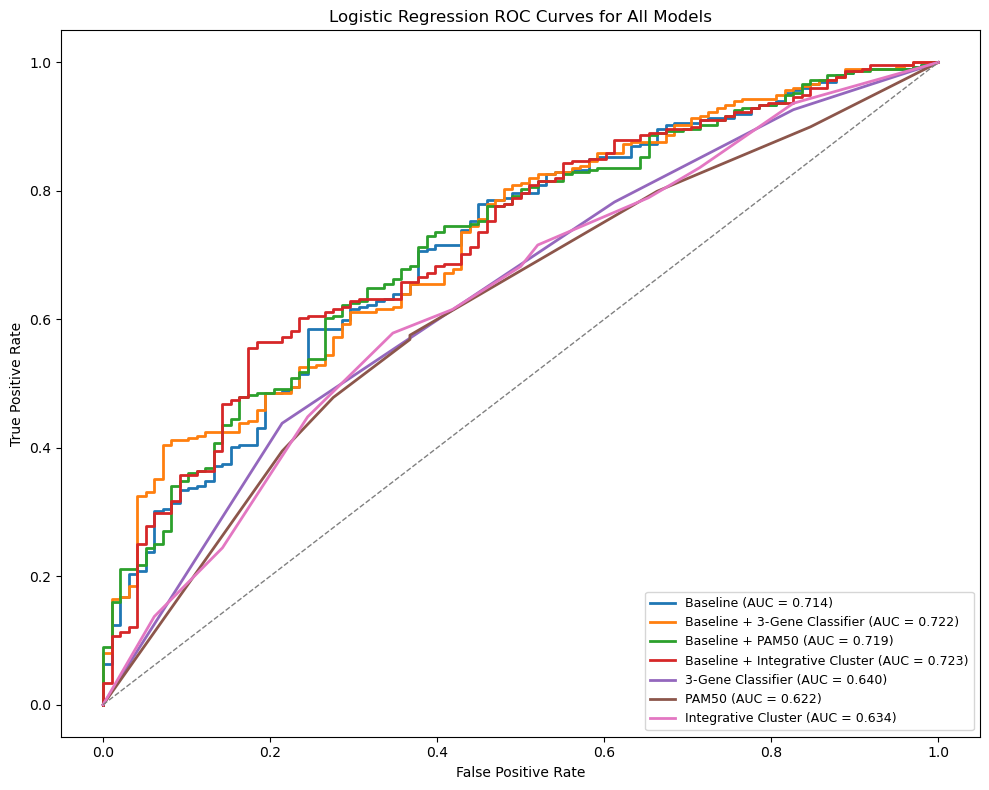

In [20]:
### Logistic Regression comparison across the 7 models

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Load the saved model matrices so this cell can run independently.
feature_sets = [
    ("Baseline", "./x1_train.csv", "./x1_test.csv"),
    ("Baseline + 3-Gene Classifier", "./x2_train.csv", "./x2_test.csv"),
    ("Baseline + PAM50", "./x3_train.csv", "./x3_test.csv"),
    ("Baseline + Integrative Cluster", "./x4_train.csv", "./x4_test.csv"),
    ("3-Gene Classifier", "./x5_train.csv", "./x5_test.csv"),
    ("PAM50", "./x6_train.csv", "./x6_test.csv"),
    ("Integrative Cluster", "./x7_train.csv", "./x7_test.csv"),
]

positive_label = ">=5 years"
y_train = pd.read_csv("./y_train.csv").iloc[:, 0]
y_test = pd.read_csv("./y_test.csv").iloc[:, 0]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
roc_curves = []

for model_name, train_path, test_path in feature_sets:
    X_train = pd.read_csv(train_path)
    X_test = pd.read_csv(test_path).reindex(columns=X_train.columns, fill_value=0)

    pipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=3000,
                    solver="liblinear",
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    )

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)
    train_prob = pipeline.predict_proba(X_train)[:, 1]
    test_prob = pipeline.predict_proba(X_test)[:, 1]

    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc",
        },
        return_train_score=False,
    )

    fpr, tpr, _ = roc_curve(y_test, test_prob, pos_label=positive_label)
    test_auc = auc(fpr, tpr)
    roc_curves.append((model_name, fpr, tpr, test_auc))

    results.append(
        {
            "Model": model_name,
            "Train_Accuracy": accuracy_score(y_train, train_pred),
            "Test_Accuracy": accuracy_score(y_test, test_pred),
            "Train_Precision": precision_score(
                y_train, train_pred, pos_label=positive_label, zero_division=0
            ),
            "Test_Precision": precision_score(
                y_test, test_pred, pos_label=positive_label, zero_division=0
            ),
            "Train_Recall": recall_score(
                y_train, train_pred, pos_label=positive_label, zero_division=0
            ),
            "Test_Recall": recall_score(
                y_test, test_pred, pos_label=positive_label, zero_division=0
            ),
            "Train_F1": f1_score(y_train, train_pred, pos_label=positive_label, zero_division=0),
            "Test_F1": f1_score(y_test, test_pred, pos_label=positive_label, zero_division=0),
            "Train_ROC_AUC": roc_auc_score(y_train, train_prob),
            "Test_ROC_AUC": roc_auc_score(y_test, test_prob),
            "CV_Accuracy_mean": cv_scores["test_accuracy"].mean(),
            "CV_Accuracy_std": cv_scores["test_accuracy"].std(),
            "CV_Precision_mean": cv_scores["test_precision"].mean(),
            "CV_Precision_std": cv_scores["test_precision"].std(),
            "CV_Recall_mean": cv_scores["test_recall"].mean(),
            "CV_Recall_std": cv_scores["test_recall"].std(),
            "CV_F1_mean": cv_scores["test_f1"].mean(),
            "CV_F1_std": cv_scores["test_f1"].std(),
            "CV_ROC_AUC_mean": cv_scores["test_roc_auc"].mean(),
            "CV_ROC_AUC_std": cv_scores["test_roc_auc"].std(),
        }
    )

results_df = pd.DataFrame(results).sort_values("CV_ROC_AUC_mean", ascending=False).reset_index(drop=True)

print("Logistic regression metrics by model")
display(
    results_df[
        [
            "Model",
            "Train_Accuracy",
            "Test_Accuracy",
            "Train_F1",
            "Test_F1",
            "Train_ROC_AUC",
            "Test_ROC_AUC",
            "CV_Accuracy_mean",
            "CV_Accuracy_std",
            "CV_F1_mean",
            "CV_F1_std",
            "CV_ROC_AUC_mean",
            "CV_ROC_AUC_std",
        ]
    ].round(4)
)

summary_df = results_df[
    [
        "Model",
        "Test_Accuracy",
        "Test_F1",
        "Test_ROC_AUC",
        "CV_Accuracy_mean",
        "CV_F1_mean",
        "CV_F1_std",
        "CV_ROC_AUC_mean",
        "CV_ROC_AUC_std",
    ]
].copy()
summary_df = summary_df.rename(
    columns={
        "Test_Accuracy": "Accuracy",
        "Test_F1": "F1",
        "Test_ROC_AUC": "ROC_AUC",
        "CV_Accuracy_mean": "CV_Accuracy",
        "CV_F1_mean": "CV_F1",
        "CV_ROC_AUC_mean": "CV_ROC_AUC",
    }
)

print("Compact summary sorted by cross-validated ROC AUC")
display(summary_df.round(4))

plt.figure(figsize=(10, 8))
for model_name, fpr, tpr, model_auc in roc_curves:
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {model_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curves for All Models")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


XGBoost metrics by model


,Model,Train_Accuracy,Test_Accuracy,Train_F1,Test_F1,Train_ROC_AUC,Test_ROC_AUC,CV_Accuracy_mean,CV_Accuracy_std,CV_F1_mean,CV_F1_std,CV_ROC_AUC_mean,CV_ROC_AUC_std
0,Baseline + PAM50,0.7677,0.6977,0.8332,0.7849,0.8437,0.7055,0.6919,0.0282,0.7828,0.0207,0.7053,0.0308
1,Baseline + Integrative Cluster,0.7689,0.6952,0.8341,0.7820,0.8402,0.7238,0.6818,0.0272,0.7724,0.0229,0.7025,0.0264
2,Baseline,0.7588,0.6927,0.8270,0.7814,0.8287,0.7106,0.6837,0.0223,0.7741,0.0189,0.6996,0.0303
3,Baseline + 3-Gene Classifier,0.7620,0.6927,0.8287,0.7790,0.8337,0.7089,0.6856,0.0257,0.7765,0.0197,0.6924,0.0335
4,Integrative Cluster,0.6206,0.6071,0.7126,0.7023,0.6479,0.6344,0.6079,0.0270,0.6996,0.0335,0.6320,0.0262
5,PAM50,0.5922,0.5844,0.6852,0.6733,0.6269,0.6199,0.5922,0.0200,0.6851,0.0170,0.6253,0.0269
6,3-Gene Classifier,0.6843,0.6851,0.7874,0.7892,0.6199,0.6400,0.5960,0.0925,0.6839,0.1158,0.6201,0.0097


Compact XGBoost summary sorted by cross-validated ROC AUC


,Model,Accuracy,F1,ROC_AUC,CV_Accuracy,CV_F1,CV_F1_std,CV_ROC_AUC,CV_ROC_AUC_std
0,Baseline + PAM50,0.6977,0.7849,0.7055,0.6919,0.7828,0.0207,0.7053,0.0308
1,Baseline + Integrative Cluster,0.6952,0.7820,0.7238,0.6818,0.7724,0.0229,0.7025,0.0264
2,Baseline,0.6927,0.7814,0.7106,0.6837,0.7741,0.0189,0.6996,0.0303
3,Baseline + 3-Gene Classifier,0.6927,0.7790,0.7089,0.6856,0.7765,0.0197,0.6924,0.0335
4,Integrative Cluster,0.6071,0.7023,0.6344,0.6079,0.6996,0.0335,0.6320,0.0262
5,PAM50,0.5844,0.6733,0.6199,0.5922,0.6851,0.0170,0.6253,0.0269
6,3-Gene Classifier,0.6851,0.7892,0.6400,0.5960,0.6839,0.1158,0.6201,0.0097


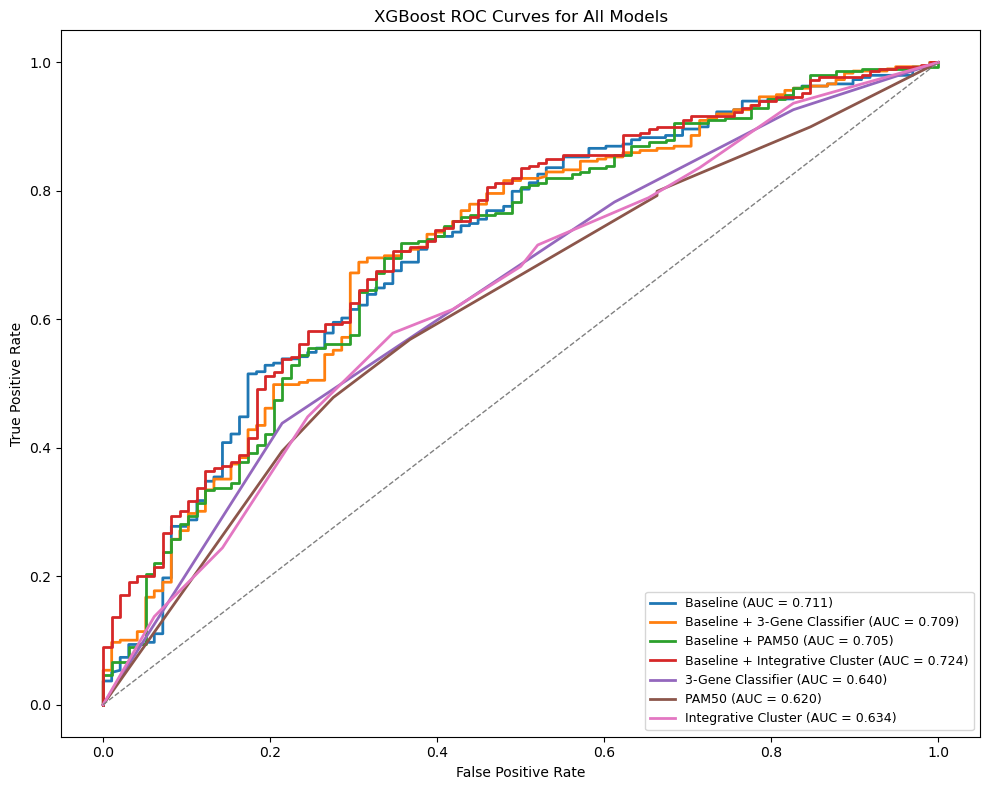

In [22]:
### XGBoost comparison across the 7 models

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    auc,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "xgboost is not installed in the notebook kernel. Install it with: pip install xgboost"
    ) from exc

# Reuse the same 7 feature matrices saved previously.
feature_sets = [
    ("Baseline", "./x1_train.csv", "./x1_test.csv"),
    ("Baseline + 3-Gene Classifier", "./x2_train.csv", "./x2_test.csv"),
    ("Baseline + PAM50", "./x3_train.csv", "./x3_test.csv"),
    ("Baseline + Integrative Cluster", "./x4_train.csv", "./x4_test.csv"),
    ("3-Gene Classifier", "./x5_train.csv", "./x5_test.csv"),
    ("PAM50", "./x6_train.csv", "./x6_test.csv"),
    ("Integrative Cluster", "./x7_train.csv", "./x7_test.csv"),
]

positive_label = ">=5 years"
y_train_raw = pd.read_csv("./y_train.csv").iloc[:, 0]
y_test_raw = pd.read_csv("./y_test.csv").iloc[:, 0]

# XGBoost expects numeric labels.
y_train_bin = (y_train_raw == positive_label).astype(int)
y_test_bin = (y_test_raw == positive_label).astype(int)

# Handle class imbalance through scale_pos_weight.
neg_count = int((y_train_bin == 0).sum())
pos_count = int((y_train_bin == 1).sum())
scale_pos_weight = (neg_count / pos_count) if pos_count > 0 else 1.0

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
roc_curves = []

for model_name, train_path, test_path in feature_sets:
    X_train = pd.read_csv(train_path)
    X_test = pd.read_csv(test_path).reindex(columns=X_train.columns, fill_value=0)

    clf = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_alpha=0.2,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    )

    clf.fit(X_train, y_train_bin)

    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)
    train_prob = clf.predict_proba(X_train)[:, 1]
    test_prob = clf.predict_proba(X_test)[:, 1]

    cv_scores = cross_validate(
        clf,
        X_train,
        y_train_bin,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc",
        },
        return_train_score=False,
        n_jobs=-1,
    )

    fpr, tpr, _ = roc_curve(y_test_bin, test_prob)
    test_auc = auc(fpr, tpr)
    roc_curves.append((model_name, fpr, tpr, test_auc))

    results.append(
        {
            "Model": model_name,
            "Train_Accuracy": accuracy_score(y_train_bin, train_pred),
            "Test_Accuracy": accuracy_score(y_test_bin, test_pred),
            "Train_Precision": precision_score(y_train_bin, train_pred, zero_division=0),
            "Test_Precision": precision_score(y_test_bin, test_pred, zero_division=0),
            "Train_Recall": recall_score(y_train_bin, train_pred, zero_division=0),
            "Test_Recall": recall_score(y_test_bin, test_pred, zero_division=0),
            "Train_F1": f1_score(y_train_bin, train_pred, zero_division=0),
            "Test_F1": f1_score(y_test_bin, test_pred, zero_division=0),
            "Train_ROC_AUC": roc_auc_score(y_train_bin, train_prob),
            "Test_ROC_AUC": roc_auc_score(y_test_bin, test_prob),
            "CV_Accuracy_mean": cv_scores["test_accuracy"].mean(),
            "CV_Accuracy_std": cv_scores["test_accuracy"].std(),
            "CV_Precision_mean": cv_scores["test_precision"].mean(),
            "CV_Precision_std": cv_scores["test_precision"].std(),
            "CV_Recall_mean": cv_scores["test_recall"].mean(),
            "CV_Recall_std": cv_scores["test_recall"].std(),
            "CV_F1_mean": cv_scores["test_f1"].mean(),
            "CV_F1_std": cv_scores["test_f1"].std(),
            "CV_ROC_AUC_mean": cv_scores["test_roc_auc"].mean(),
            "CV_ROC_AUC_std": cv_scores["test_roc_auc"].std(),
        }
    )

results_df_xgb = (
    pd.DataFrame(results)
    .sort_values("CV_ROC_AUC_mean", ascending=False)
    .reset_index(drop=True)
)

print("XGBoost metrics by model")
display(
    results_df_xgb[
        [
            "Model",
            "Train_Accuracy",
            "Test_Accuracy",
            "Train_F1",
            "Test_F1",
            "Train_ROC_AUC",
            "Test_ROC_AUC",
            "CV_Accuracy_mean",
            "CV_Accuracy_std",
            "CV_F1_mean",
            "CV_F1_std",
            "CV_ROC_AUC_mean",
            "CV_ROC_AUC_std",
        ]
    ].round(4)
)

summary_df_xgb = results_df_xgb[
    [
        "Model",
        "Test_Accuracy",
        "Test_F1",
        "Test_ROC_AUC",
        "CV_Accuracy_mean",
        "CV_F1_mean",
        "CV_F1_std",
        "CV_ROC_AUC_mean",
        "CV_ROC_AUC_std",
    ]
].copy()
summary_df_xgb = summary_df_xgb.rename(
    columns={
        "Test_Accuracy": "Accuracy",
        "Test_F1": "F1",
        "Test_ROC_AUC": "ROC_AUC",
        "CV_Accuracy_mean": "CV_Accuracy",
        "CV_F1_mean": "CV_F1",
        "CV_ROC_AUC_mean": "CV_ROC_AUC",
    }
)

print("Compact XGBoost summary sorted by cross-validated ROC AUC")
display(summary_df_xgb.round(4))

plt.figure(figsize=(10, 8))
for model_name, fpr, tpr, model_auc in roc_curves:
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {model_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curves for All Models")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()
